In [1]:
from pathlib import Path
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.svm import LinearSVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path.cwd().parent / "data"
df = pd.read_csv(DATA_DIR / "processed" / "cleaned_taxi_data.csv")
df.head(5)

,index_left,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,BoroName
0,4217,id1693416,2,2016-01-12 22:57:13,2016-01-12 23:33:06,1,-73.979324,40.727631,-74.074028,40.640224,N,35.883333,Staten Island
1,16494,id1973056,2,2016-03-22 15:35:52,2016-03-22 16:53:17,1,-73.789642,40.647121,-74.135986,40.624981,N,77.416667,Staten Island
2,17985,id3759847,2,2016-02-04 22:00:26,2016-02-04 22:48:18,2,-73.984749,40.742130,-74.076393,40.599159,N,47.866667,Staten Island
3,19015,id3330882,2,2016-04-02 08:47:43,2016-04-02 08:50:23,1,-74.073433,40.615421,-74.073433,40.615421,N,2.666667,Staten Island
4,19701,id0778469,1,2016-01-01 19:46:50,2016-01-01 20:33:26,1,-73.991974,40.749928,-74.115303,40.574230,N,46.600000,Staten Island


In [3]:
def haversine_form(lat1,long1,lat2,long2):
    lat1 , long1,lat2,long2 = map(np.radians, [lat1, long1, lat2, long2])
    dlat = lat2-lat1
    dlong = long2-long1
    a  = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2)*np.sin(dlong/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 3956
    return c*r

In [4]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df.drop(['vendor_id','dropoff_datetime','store_and_fwd_flag'],axis =1,inplace=True)
df['distance'] =  haversine_form(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_latitude'],df['dropoff_longitude'])
df['day_of_week'] = df['pickup_datetime'].dt.day_of_week
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['is_rush_hour'] = df['pickup_hour'].isin([7,8,9,16,17,18,19]).astype(int)
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [5]:
X = df.drop(['trip_duration','id','pickup_datetime','index_left'],axis=1)
y = df['trip_duration']
categorical = X.select_dtypes(include=['str']).columns.to_list()
X[categorical]= X[categorical].astype('category')
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)


In [6]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1442002 entries, 0 to 1442001
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype   
---  ------             --------------    -----   
 0   passenger_count    1442002 non-null  int64   
 1   pickup_longitude   1442002 non-null  float64 
 2   pickup_latitude    1442002 non-null  float64 
 3   dropoff_longitude  1442002 non-null  float64 
 4   dropoff_latitude   1442002 non-null  float64 
 5   BoroName           1442002 non-null  category
 6   distance           1442002 non-null  float64 
 7   day_of_week        1442002 non-null  int32   
 8   pickup_hour        1442002 non-null  int32   
 9   is_rush_hour       1442002 non-null  int64   
 10  is_weekend         1442002 non-null  int64   
dtypes: category(1), float64(5), int32(2), int64(3)
memory usage: 100.4 MB


In [7]:
XGB_PARAM  = {'lambda': 3.3633401045158903e-07,
               'alpha': 0.01121276561148217, 
               'subsample': 0.9405758686374284, 
               'max_depth': 7,
                 'colsample_bytree': 0.9054986003043914}

HIST_PARAM = {'learning_rate': 0.20822254137715343,
               'l2_regularization': 1.5234018422544593,
                 'max_leaf_nodes': 100,
                   'max_depth': 10, 
                   'min_samples_leaf': 33}

In [8]:
ategorical = X.select_dtypes(include=['str','category']).columns.to_list()
numerical = X.select_dtypes(include=['float','int']).columns.to_list()
categorical_enc = ColumnTransformer([("category",OneHotEncoder(sparse_output=False),categorical)],remainder='passthrough',verbose_feature_names_out=False)
numerical_enc = ColumnTransformer([("numerical",StandardScaler(),numerical)],remainder='passthrough',verbose_feature_names_out=False)
pipeline = Pipeline(
    [('encoder',categorical_enc),
     ('scaler',numerical_enc),
     ('model',LinearRegression())]
)
pipeline.set_output(transform='pandas')

svpipeline = Pipeline(
    [('encoder',categorical_enc),
     ('scaler',numerical_enc),
     ('model',LinearSVR())]
)
svpipeline.set_output(transform='pandas')


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [9]:
models = {"Linear":pipeline,
          "Hist":HistGradientBoostingRegressor(**HIST_PARAM,categorical_features=categorical,random_state=42)
          ,"xgboost":xgb.XGBRegressor(**XGB_PARAM,enable_categorical =True,random_state=42,n_jobs=-1),
          "SVR": svpipeline}
result = {}
for i in models:
        print(f"Training {i}")
        models[i].fit(X_train,y_train)
        prediction = models[i].predict(X_test)
        mae = round(mean_absolute_error(y_test,prediction),2)
        result[i]=mae

Training Linear
Training Hist
Training xgboost
Training SVR


In [29]:
comp = pd.DataFrame.from_dict(result, orient='index', columns=['RMSE']).reset_index()
comp.columns = ['Model', 'MAE']
comp.sort_values(by="MAE",ascending=False,inplace=True)

In [30]:
comp

,Model,MAE
0,Linear,4.59
3,SVR,4.43
2,xgboost,3.10
1,Hist,3.08


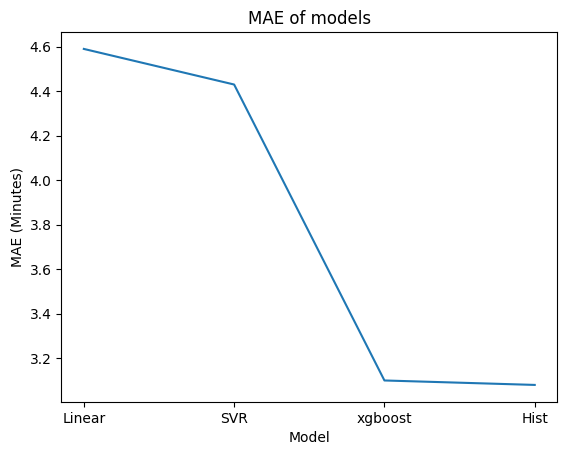

In [32]:
FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sns.lineplot(comp ,x ='Model',y='MAE')
plt.ylabel("MAE (Minutes)")
plt.title("MAE of models")
plt.savefig(FIGURES_DIR / "model_comp.png")